In [6]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

import os
from pathlib import Path

# Try to detect repo root assuming this notebook is in `notebooks/`
NOTEBOOK_DIR = Path(os.getcwd())
if (NOTEBOOK_DIR / "notebooks").exists():
    # If you're running from repo root
    ROOT_DIR = NOTEBOOK_DIR
elif (NOTEBOOK_DIR.name == "notebooks") and (NOTEBOOK_DIR.parent / "app").exists():
    # If you're running with CWD = notebooks/
    ROOT_DIR = NOTEBOOK_DIR.parent
else:
    # Fallback: use current working directory
    ROOT_DIR = NOTEBOOK_DIR

DATA_DIR = ROOT_DIR / "data"
ML_DIR = ROOT_DIR / "app" / "ml"

DATA_DIR.mkdir(exist_ok=True, parents=True)
ML_DIR.mkdir(exist_ok=True, parents=True)

ROOT_DIR, DATA_DIR, ML_DIR

(WindowsPath('c:/AI/Agentic/autonomous-route-optimization-agent'),
 WindowsPath('c:/AI/Agentic/autonomous-route-optimization-agent/data'),
 WindowsPath('c:/AI/Agentic/autonomous-route-optimization-agent/app/ml'))

In [7]:
def generate_synthetic_telemetry(n_rows: int = 5000, seed: int = 42) -> pd.DataFrame:
    """
    Generate synthetic 'trip' data with features similar to fleet telemetry:
    origin, destination, distance, time of day, day of week, traffic level,
    plus simple route history features.
    """
    rng = np.random.default_rng(seed)

    origins = rng.integers(1, 50, size=n_rows)
    destinations = rng.integers(1, 50, size=n_rows)
    distance_km = rng.uniform(1, 50, size=n_rows)
    time_of_day = rng.integers(0, 24, size=n_rows)
    day_of_week = rng.integers(0, 7, size=n_rows)
    traffic_level = rng.integers(0, 3, size=n_rows)  # 0=low, 1=medium, 2=high

    base_speed = 40.0  # km/h
    traffic_factor = 1.0 + 0.3 * traffic_level

    rush_hour_mask = ((time_of_day >= 7) & (time_of_day <= 9)) | (
        (time_of_day >= 16) & (time_of_day <= 18)
    )
    rush_hour_penalty = np.where(rush_hour_mask, 1.3, 1.0)

    # Base ETA in minutes from physics-ish model
    base_eta_min = (distance_km / base_speed) * 60.0 * traffic_factor * rush_hour_penalty

    # Route history features
    route_id = origins * 1000 + destinations
    route_noise = (route_id % 10) / 10.0  # 0.0 .. 0.9

    avg_historical_eta_min = base_eta_min * (0.9 + 0.2 * route_noise)
    num_past_trips = rng.integers(5, 200, size=n_rows)
    on_time_ratio = 0.7 + 0.3 * route_noise  # 0.7 .. 1.0

    eta_noise = rng.normal(0, 3, size=n_rows)
    eta_min = base_eta_min * (1.0 + (1 - on_time_ratio) * 0.2) + eta_noise
    eta_min = np.clip(eta_min, 5, None)

    df = pd.DataFrame(
        {
            "origin": origins,
            "destination": destinations,
            "distance_km": distance_km,
            "time_of_day": time_of_day,
            "day_of_week": day_of_week,
            "traffic_level": traffic_level,
            "avg_historical_eta_min": avg_historical_eta_min,
            "num_past_trips": num_past_trips,
            "on_time_ratio": on_time_ratio,
            "eta_min": eta_min,
        }
    )
    return df


df = generate_synthetic_telemetry(n_rows=5000)
df.head()

,origin,destination,distance_km,time_of_day,day_of_week,traffic_level,avg_historical_eta_min,num_past_trips,on_time_ratio,eta_min
0,5,10,11.689310,0,6,0,15.780569,169,0.70,13.108686
1,38,2,33.483457,17,5,1,79.787730,93,0.76,87.770766
2,33,31,38.576214,5,2,2,85.176282,140,0.73,92.337189
3,22,34,9.165171,17,0,0,17.514642,192,0.82,24.640095
4,22,38,3.149056,13,1,0,5.006999,14,0.94,5.417740


In [8]:
# Save to CSV so it is consistent with the script-based pipeline
csv_path = DATA_DIR / "synthetic_trips_notebook.csv"
df.to_csv(csv_path, index=False)

csv_path, df.shape, df.describe().T

(WindowsPath('c:/AI/Agentic/autonomous-route-optimization-agent/data/synthetic_trips_notebook.csv'),
 (5000, 10),
                          count        mean        std       min        25%  \
 origin                  5000.0   24.936800  14.182914  1.000000  13.000000   
 destination             5000.0   24.707200  13.974381  1.000000  13.000000   
 distance_km             5000.0   25.432911  14.108835  1.015407  13.182018   
 time_of_day             5000.0   11.594200   6.909781  0.000000   6.000000   
 day_of_week             5000.0    3.021800   2.003429  0.000000   1.000000   
 traffic_level           5000.0    1.003400   0.823361  0.000000   0.000000   
 avg_historical_eta_min  5000.0   53.014140  32.946108  1.422241  25.976144   
 num_past_trips          5000.0  101.220600  56.447845  5.000000  51.000000   
 on_time_ratio           5000.0    0.835576   0.083981  0.700000   0.760000   
 eta_min                 5000.0   55.425776  33.939628  5.000000  27.675323   
 
               

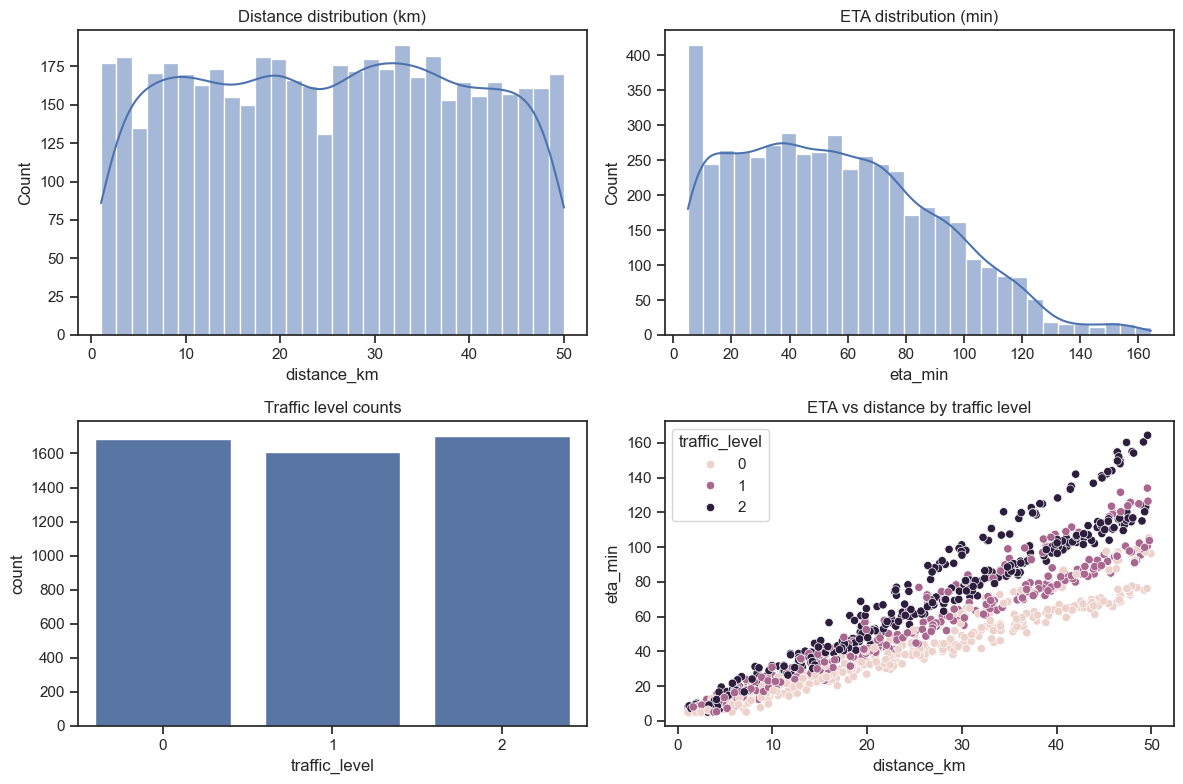

In [9]:
sns.set(style="ticks")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df["distance_km"], bins=30, ax=axes[0, 0], kde=True)
axes[0, 0].set_title("Distance distribution (km)")

sns.histplot(df["eta_min"], bins=30, ax=axes[0, 1], kde=True)
axes[0, 1].set_title("ETA distribution (min)")

sns.countplot(x="traffic_level", data=df, ax=axes[1, 0])
axes[1, 0].set_title("Traffic level counts")

sns.scatterplot(
    x="distance_km",
    y="eta_min",
    hue="traffic_level",
    data=df.sample(min(1000, len(df))),
    ax=axes[1, 1],
)
axes[1, 1].set_title("ETA vs distance by traffic level")

plt.tight_layout()
plt.show()

In [10]:
FEATURE_COLS = [
    "origin",
    "destination",
    "distance_km",
    "time_of_day",
    "day_of_week",
    "traffic_level",
    "avg_historical_eta_min",
    "num_past_trips",
    "on_time_ratio",
]

X = df[FEATURE_COLS]
y = df["eta_min"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=42,
)

model

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [11]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE on test set: {mae:.2f} minutes")

MAE on test set: 2.54 minutes


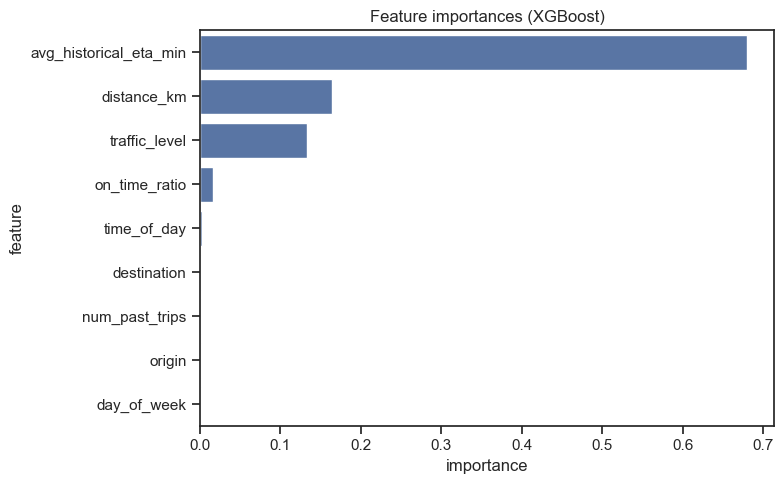

In [12]:
importances = model.feature_importances_

fi_df = pd.DataFrame(
    {"feature": FEATURE_COLS, "importance": importances}
).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x="importance", y="feature", data=fi_df)
plt.title("Feature importances (XGBoost)")
plt.tight_layout()
plt.show()

In [13]:
model_path = ML_DIR / "eta_model_from_notebook.joblib"
joblib.dump(model, model_path)

model_path

WindowsPath('c:/AI/Agentic/autonomous-route-optimization-agent/app/ml/eta_model_from_notebook.joblib')

In [14]:
sample = df.sample(5, random_state=42)[FEATURE_COLS]
sample_preds = model.predict(sample)

pd.concat(
    [
        sample.reset_index(drop=True),
        pd.Series(sample_preds, name="predicted_eta_min"),
    ],
    axis=1,
)

,origin,destination,distance_km,time_of_day,day_of_week,traffic_level,avg_historical_eta_min,num_past_trips,on_time_ratio,predicted_eta_min
0,13,48,17.022467,7,5,0,35.185438,56,0.94,32.584087
1,19,41,8.140268,15,1,2,17.973712,62,0.73,22.066286
2,19,14,2.989809,16,2,1,7.427583,119,0.82,8.995152
3,49,43,2.873047,15,3,2,6.619500,39,0.79,8.529543
4,28,40,21.312853,13,1,2,46.035763,49,0.70,53.535931
